In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import getpass
import act

In [2]:
# Note - recommended ARM Live token to be set as an environmental variable

# Check for env variables, otherwise set your username and token here!
if "ARM_USERNAME" in os.environ:
    arm_username = os.getenv("ARM_USERNAME")
else:
    arm_username = input("Enter ARM username: ").strip()
if "ARM_TOKEN" in os.environ:
    arm_token = os.getenv("ARM_TOKEN")
else:
    arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

# Set the datastream and start/enddates
mw1 = 'nsamwrlosC1.b1'  ## mwrlos
mw2 = "nsamwrret1liljclouC1.c2"  ## MWRRET1LILJCLOU
mw3 = "nsamwrhfC1.b1"  #"MWRHF"
weather_data = "nsametC1.b1"
cloud_phase = "nsathermocldphaseC1"

startdate = '2015-06-10'
enddate = '2015-06-20'

# Use ACT to easily download the data.  Watch for the data citation!  Show some support
# for ARM's instrument experts and cite their data if you use it in a publication
result_mr1 = act.discovery.download_arm_data(arm_username, arm_token, mw1, startdate, enddate)
print('1')
result_mr2 = act.discovery.download_arm_data(arm_username, arm_token, mw2, startdate, enddate)
print('2')
result_mr3 = act.discovery.download_arm_data(arm_username, arm_token, mw3, startdate, enddate)
print('3')
wd_1 = act.discovery.download_arm_data(arm_username, arm_token, weather_data, startdate, enddate)
print('1')

cloud_phase_1 = act.discovery.download_arm_data(arm_username, arm_token, cloud_phase, startdate, enddate)
print('cloud_phase')

Enter ARM username:  ssingh45
Enter ARM token (hidden):  ········


[DOWNLOADING] nsamwrlosC1.b1.20150610.000040.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150611.000000.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150612.000011.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150613.000005.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150614.000000.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150615.000000.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150616.000000.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150617.000017.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150618.000032.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150619.000020.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150620.000000.cdf

If you use these data to prepare a publication, please cite:

Cadeddu, M. Microwave Radiometer (MWRLOS), 2015-06-10 to 2015-06-20, North Slope
Alaska (NSA), Central Facility, Barrow AK (C1). Atmospheric Radiation
Measurement (ARM) User Facility. https://doi.org/10.5439/1999490

1
[DOWNLOADING] nsamwrret1liljclouC1.c2.20150610.000040.nc
[DOWNLOADING] nsamwrret1liljclouC1.c2.20150611.000000.nc
[DOWNLOADING] nsamwrret1liljclouC1.c2.20150612.000011.nc
[DOWNLOA

In [3]:
ds_mr1 = act.io.read_arm_netcdf(result_mr1)
ds_mr2 = act.io.read_arm_netcdf(result_mr2)
ds_met1 = act.io.read_arm_netcdf(wd_1)
cloud_phase_1 = act.io.read_arm_netcdf(cloud_phase_1)

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed


## precipation

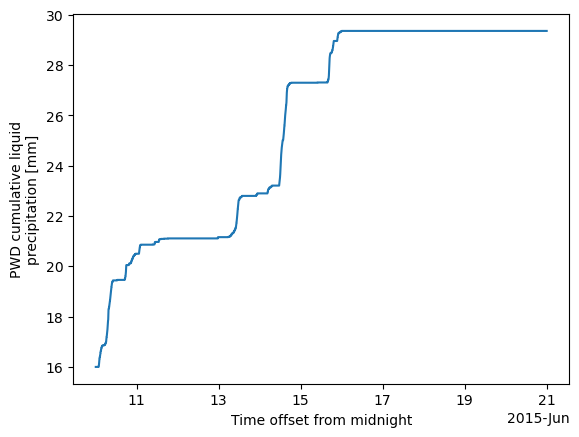

In [4]:
ds_met1["pwd_cumul_rain"].plot()

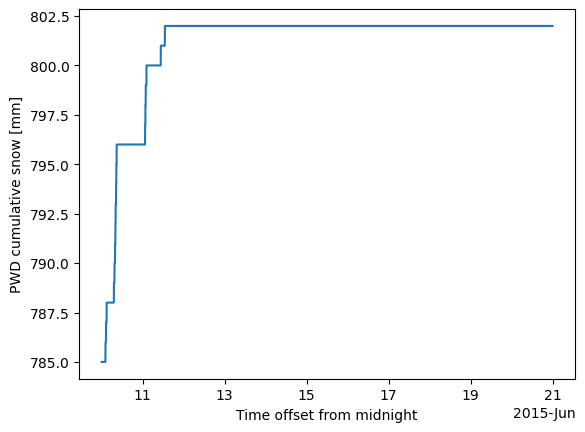

In [5]:
ds_met1["pwd_cumul_snow"].plot()

## radiometer

In [6]:
ds_mr1
# vap, qc_vap, liq, qc_liq

<xarray.Dataset> Size: 7MB
Dimensions:      (time: 41186)
Coordinates:
  * time         (time) datetime64[ns] 329kB 2015-06-10T00:00:40 ... 2015-06-...
Data variables: (12/41)
    base_time    (time) datetime64[ns] 329kB 2015-06-10 ... 2015-06-20
    time_offset  (time) datetime64[ns] 329kB 2015-06-10T00:00:40 ... 2015-06-...
    qc_time      (time) int32 165kB dask.array<chunksize=(4195,), meta=np.ndarray>
    tknd         (time) float32 165kB dask.array<chunksize=(4195,), meta=np.ndarray>
    qc_tknd      (time) int32 165kB dask.array<chunksize=(4195,), meta=np.ndarray>
    tkxc         (time) float32 165kB dask.array<chunksize=(4195,), meta=np.ndarray>
    ...           ...
    tnd_nom31    (time) float32 165kB dask.array<chunksize=(4195,), meta=np.ndarray>
    tc23         (time) float32 165kB dask.array<chunksize=(4195,), meta=np.ndarray>
    tc31         (time) float32 165kB dask.array<chunksize=(4195,), meta=np.ndarray>
    lat          (time) float32 165kB 71.32 71.32 71.32 ... 71.32 71.32 71.32
    lon          (time) float32 165kB -156.6 -156.6 -156.6 ... -156.6 -156.6
    alt          (time) float32 165kB 8.0 8.0 8.0 8.0 8.0 ... 8.0 8.0 8.0 8.0
Attributes: (12/55)
    command_line:                       mwr_ingest -s nsa -f C1
    process_version:                    ingest-mwr-2.2-0.el6
    ingest_software:                    ingest-mwr-2.2-0.el6
    dod_version:                        mwrlos-b1-2.3
    site_id:                            nsa
    facility_id:                        C1: Barrow, Alaska
    ...                                 ...
    datastream:                         nsamwrlosC1.b1
    history:                            created by user dsmgr on machine ruby...
    _file_dates:                        ['20150610', '20150611', '20150612', ...
    _file_times:                        ['000040', '000000', '000011', '00000...
    _datastream:                        nsamwrlosC1.b1
    _arm_standards_flag:                1

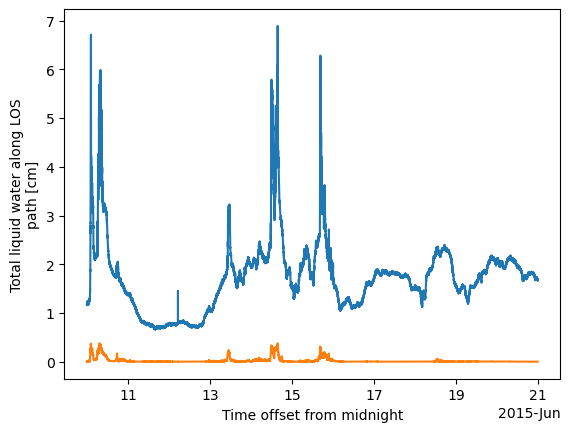

In [7]:
ds_mr1['vap'].plot()
ds_mr1['liq'].plot()

In [8]:
ds_mr2

<xarray.Dataset> Size: 49MB
Dimensions:                  (time: 41186, nlevels: 54, nvbias: 40)
Coordinates:
  * time                     (time) datetime64[ns] 329kB 2015-06-10T00:00:40 ...
Dimensions without coordinates: nlevels, nvbias
Data variables: (12/83)
    base_time                (time) datetime64[ns] 329kB 2015-06-10 ... 2015-...
    time_offset              (time) datetime64[ns] 329kB 2015-06-10T00:00:40 ...
    qc_time                  (time) int32 165kB dask.array<chunksize=(4195,), meta=np.ndarray>
    hour                     (time) float32 165kB dask.array<chunksize=(4195,), meta=np.ndarray>
    level_height             (time, nlevels) float32 9MB dask.array<chunksize=(4195, 54), meta=np.ndarray>
    be_pwv                   (time) float32 165kB dask.array<chunksize=(4195,), meta=np.ndarray>
    ...                       ...
    vbias_hour               (time, nvbias) float32 7MB dask.array<chunksize=(4195, 40), meta=np.ndarray>
    vbias_23                 (time, nvbias) float32 7MB dask.array<chunksize=(4195, 40), meta=np.ndarray>
    vbias_31                 (time, nvbias) float32 7MB dask.array<chunksize=(4195, 40), meta=np.ndarray>
    lat                      (time) float32 165kB 71.32 71.32 ... 71.32 71.32
    lon                      (time) float32 165kB -156.6 -156.6 ... -156.6
    alt                      (time) float32 165kB 8.0 8.0 8.0 ... 8.0 8.0 8.0
Attributes: (12/45)
    command_line:                                         mwrret -d 20150610 ...
    date_created:                                         Mon Nov 26 09:41:54...
    process_version:                                      $Id: aer_mwr_retrie...
    site_id:                                              nsa
    facility_id:                                          C1
    ancio_version:                                        \n Ancio library ve...
    ...                                                   ...
    doi:                                                  10.5439/1027369
    history:                                              $Id: aer_mwr_retrie...
    _file_dates:                                          ['20150610', '20150...
    _file_times:                                          ['000040', '000000'...
    _datastream:                                          act_datastream
    _arm_standards_flag:                                  0

In [9]:
# ds_mr2['cloud_base_height'].sel(time=slice('2015-06-12T00:00', '2015-06-17T00:00')).plot()

(0.0, 5.0)

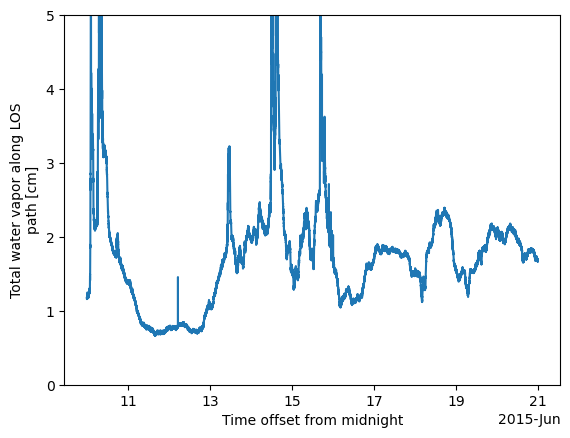

In [10]:
ds_mr2['orig_pwv'].plot()
plt.ylim(0, 5)

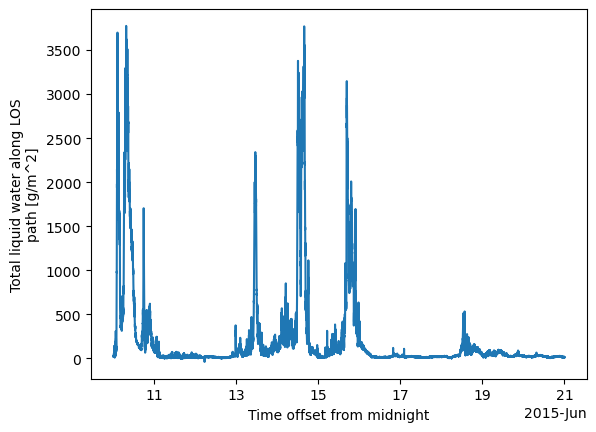

In [11]:
ds_mr2['orig_lwp'].plot()
# plt.ylim(0, 5)

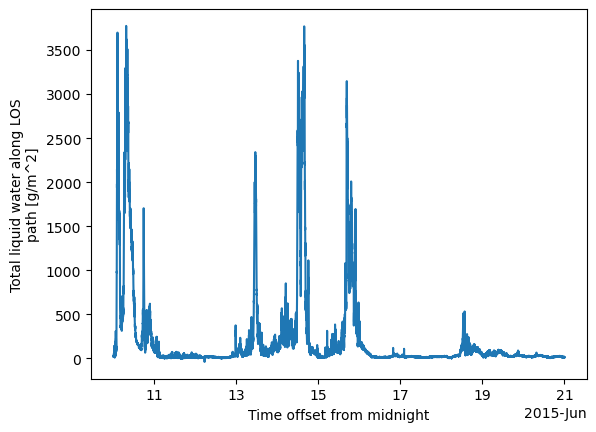

In [12]:
ds_mr2['orig_lwp'].plot()
# plt.ylim(0, 5)

In [13]:
cloud_phase_1

<xarray.Dataset> Size: 4GB
Dimensions:                           (time: 31680, bound: 2, layer: 10,
                                       height: 596)
Coordinates:
  * time                              (time) datetime64[ns] 253kB 2015-06-10 ...
  * height                            (height) float32 2kB 0.16 0.19 ... 18.01
  * layer                             (layer) int32 40B 0 1 2 3 4 5 6 7 8 9
Dimensions without coordinates: bound
Data variables: (12/65)
    base_time                         (time) datetime64[ns] 253kB 2015-06-10 ...
    time_offset                       (time) datetime64[ns] 253kB 2015-06-10 ...
    time_bounds                       (time, bound) object 507kB dask.array<chunksize=(120, 2), meta=np.ndarray>
    cloud_layer_heights               (time, layer, bound) float32 3MB dask.array<chunksize=(120, 10, 2), meta=np.ndarray>
    cloud_mask                        (time, height) float32 76MB dask.array<chunksize=(120, 596), meta=np.ndarray>
    cloud_phase_mplgr                 (time, height) float32 76MB dask.array<chunksize=(120, 596), meta=np.ndarray>
    ...                                ...
    qc_mwr_lwp_be                     (time) int32 127kB dask.array<chunksize=(120,), meta=np.ndarray>
    mwr_pwv_be                        (time) float32 127kB dask.array<chunksize=(120,), meta=np.ndarray>
    qc_mwr_pwv_be                     (time) int32 127kB dask.array<chunksize=(120,), meta=np.ndarray>
    lat                               (time) float32 127kB 71.32 71.32 ... 71.32
    lon                               (time) float32 127kB -156.6 ... -156.6
    alt                               (time) float32 127kB 8.0 8.0 ... 8.0 8.0
Attributes: (12/59)
    command_line:                                      thermocldphase -n ther...
    Conventions:                                       ARM-1.3
    process_version:                                   thermocldphase-1.2.1
    dod_version:                                       thermocldphase-c0-1.1
    input_datastreams:                                 nsaarsclkazr1kolliasC1...
    site_id:                                           nsa
    ...                                                ...
    base_backscatter_grad_threshold_comment:           Threshold of backscatt...
    history:                                           created by user levin ...
    _file_dates:                                       ['20150610', '20150611...
    _file_times:                                       ['000000', '000000', '...
    _datastream:                                       nsathermocldphaseC1.c0
    _arm_standards_flag:                               1

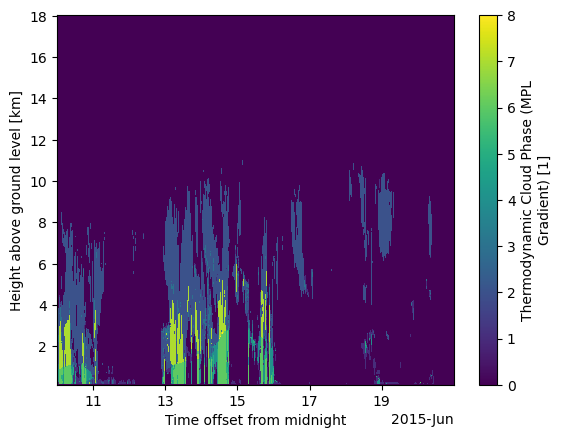

In [14]:
cloud_phase_1["cloud_phase_mplgr"].transpose().plot()
# flag_values :
#     [0 1 2 3 4 5 6 7 8]
# flag_meanings :
#     clear_sky liquid ice mixed_phase drizzle liquid_drizzle rain snow unknown


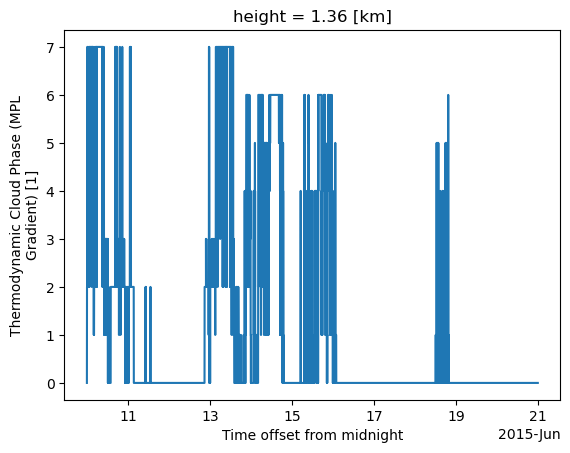

In [15]:
cloud_phase_1["cloud_phase_mplgr"][:, 40].plot()

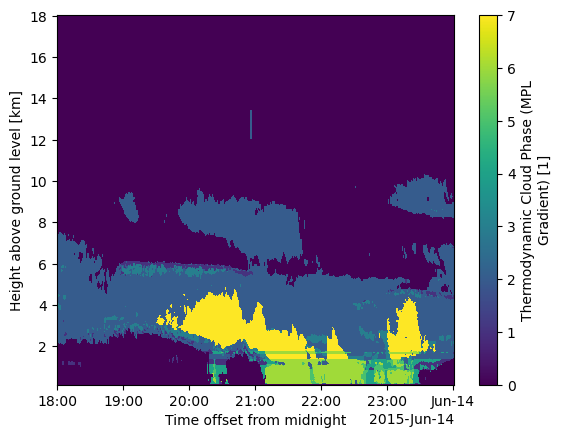

In [16]:
cloud_phase_1["cloud_phase_mplgr"].sel(time=slice('2015-06-13T18:00', '2015-06-14T00:00')).transpose().plot()

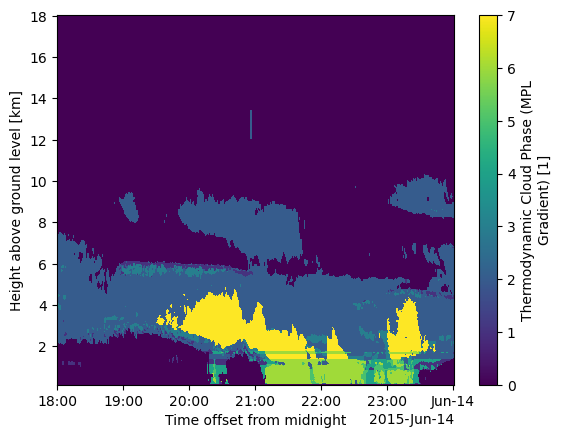

In [17]:
cloud_phase_1["cloud_phase_mplgr"].sel(time=slice('2015-06-13T18:00', '2015-06-14T00:00')).transpose().plot()

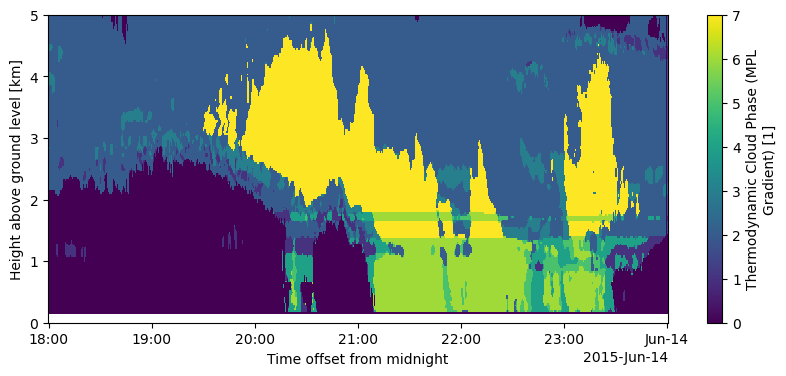

In [18]:
xx = cloud_phase_1["cloud_phase_mplgr"].sel(time=slice('2015-06-13T18:00', '2015-06-14T00:00'))
threshold = 7
da_masked = xx.where(xx <= threshold, other=np.nan)
plt.figure(figsize=(10, 4))
da_masked.transpose().plot(ylim=(0, 5))


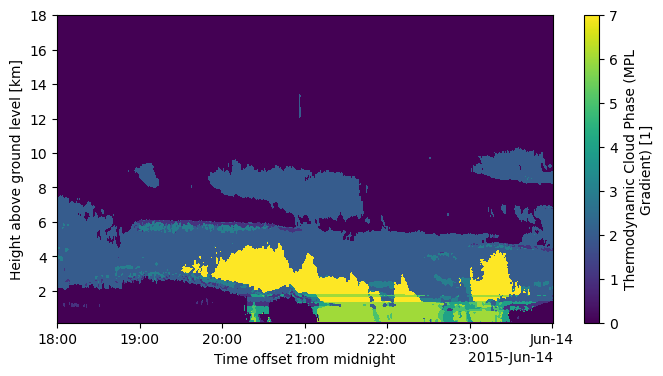

In [19]:
threshold = 7
da_masked = xx.where(xx <= threshold, other=np.nan)
plt.figure(figsize=(8, 4))
da_masked.transpose().plot()

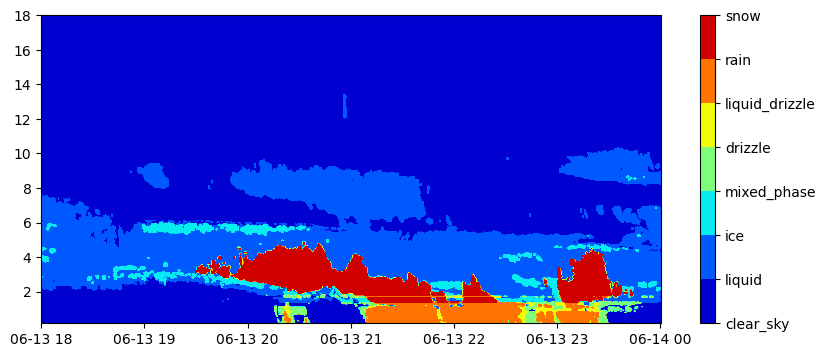

In [20]:
plt.figure(figsize=(10, 4))
levels = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
contour_filled = plt.contourf(np.array(xx.time), np.array(xx.height), np.array(xx.transpose()), levels=levels, cmap="jet")

# 3. Create the colorbar
cbar = plt.colorbar(contour_filled)
cbar.set_ticks([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])

# 5. Replace those tick positions with your custom text
cbar.set_ticklabels(["clear_sky", "liquid", "ice", "mixed_phase", "drizzle", "liquid_drizzle", "rain", "snow"])

plt.title('')
plt.show()


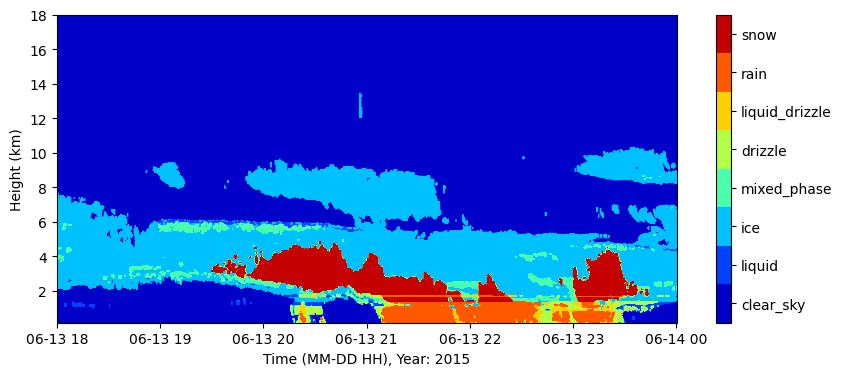

In [21]:
plt.figure(figsize=(10, 4))
levels = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
contour_filled = plt.contourf(np.array(xx.time), np.array(xx.height), np.array(xx.transpose())+0.5, levels=levels, cmap="jet")

# 3. Create the colorbar
cbar = plt.colorbar(contour_filled)
cbar.set_ticks(np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])+0.5)

# 5. Replace those tick positions with your custom text
cbar.set_ticklabels(["clear_sky", "liquid", "ice", "mixed_phase", "drizzle", "liquid_drizzle", "rain", "snow"])

plt.title('')
plt.xlabel('Time (MM-DD HH), Year: 2015')
plt.ylabel('Height (km)')
plt.ylim()
plt.show()



In [22]:
## lwp 